# Notebook 01 — Data Preprocessing

Load raw activity, alarm, and flag data. Compute data quality report.
Generate coverage heatmap (Figure F1).

In [1]:
#Setup 

import os
import subprocess

# Install extra libraries not pre-installed on Kaggle
subprocess.run(["pip", "install", "shap", "streamlit", "imbalanced-learn"],
               capture_output=True)

# Create working directories
for d in ["/kaggle/working/src",
          "/kaggle/working/results/figures",
          "/kaggle/working/results/tables",
          "/kaggle/working/poc_app/assets"]:
    os.makedirs(d, exist_ok=True)

print("Directories ready")
print(os.listdir("/kaggle/input/datasets/rimshakaokab/vivago-data"))

Directories ready
['wellbeing_flags.csv', 'activity_data.csv', 'alarm_events.csv']


In [2]:
# Create src folder and __init__.py
import os

os.makedirs('/kaggle/working/src', exist_ok=True)

with open('/kaggle/working/src/__init__.py', 'w') as f:
    f.write('')  # empty file

print("src folder created")

src folder created


In [3]:
%%writefile /kaggle/working/src/data_loader.py
# Add source files
# Create data_loader.py
"""
data_loader.py
--------------
Data loading for the Vivago Wellbeing Risk Prediction project.
Detects Kaggle vs local VS Code environment and returns correct filesystem paths.
All data files are CSV format.
"""

from pathlib import Path
import pandas as pd
import numpy as np


def get_paths() -> dict:
    """
    Detect runtime environment and return correct filesystem paths.

    Returns
    -------
    dict
        Keys: DATA_DIR, WORKING_DIR, FIGURES_DIR, TABLES_DIR, POC_DIR
    """
    if Path("/kaggle/input/datasets/rimshakaokab/vivago-data").exists():
        # Kaggle environment
        DATA_DIR    = Path("/kaggle/input/datasets/rimshakaokab/vivago-data")
        WORKING_DIR = Path("/kaggle/working")
    else:
        # Local VS Code environment
        PROJECT_ROOT = Path(__file__).resolve().parent.parent
        DATA_DIR     = PROJECT_ROOT / "vivago_data"
        WORKING_DIR  = PROJECT_ROOT / "working_local"

    FIGURES_DIR = WORKING_DIR / "results" / "figures"
    TABLES_DIR  = WORKING_DIR / "results" / "tables"
    POC_DIR     = WORKING_DIR / "poc_app"

    # Create output directories if they do not exist
    for d in [FIGURES_DIR, TABLES_DIR, POC_DIR, POC_DIR / "assets"]:
        d.mkdir(parents=True, exist_ok=True)

    return {
        "DATA_DIR":    DATA_DIR,
        "WORKING_DIR": WORKING_DIR,
        "FIGURES_DIR": FIGURES_DIR,
        "TABLES_DIR":  TABLES_DIR,
        "POC_DIR":     POC_DIR,
    }


# Module-level constants resolved once on import
_PATHS      = get_paths()
DATA_DIR    = _PATHS["DATA_DIR"]
WORKING_DIR = _PATHS["WORKING_DIR"]
FIGURES_DIR = _PATHS["FIGURES_DIR"]
TABLES_DIR  = _PATHS["TABLES_DIR"]
POC_DIR     = _PATHS["POC_DIR"]

ACTIVITY_FILE = DATA_DIR / "activity_data.csv"
ALARMS_FILE   = DATA_DIR / "alarm_events.csv"
FLAGS_FILE    = DATA_DIR / "wellbeing_flags.csv"

# Alarm type constants
MODELING_ALARM_TYPES = ["automatic_inactivity", "manual_alarm", "wellbeing_change"]
TARGET_ALARM_TYPES   = ["automatic_inactivity"]

# Helsinki timezone
_TZ_HKI = "Europe/Helsinki"


def load_activity_data(path: Path = None, nrows: int = None) -> pd.DataFrame:
    """
    Load activity data from CSV with environment-appropriate chunking.

    Parameters
    ----------
    path : Path, optional
        Path to activity_data.csv. Defaults to ACTIVITY_FILE.
    nrows : int, optional
        If provided, load only the first nrows rows (local testing mode).
        If None (Kaggle), uses chunked loading with chunksize=500_000.

    Returns
    -------
    pd.DataFrame
        Columns: user_id, timestamp_hki, activity_level, state, date, hour.
        Sorted by [user_id, timestamp_hki].
    """
    if path is None:
        path = ACTIVITY_FILE

    if not path.exists():
        raise FileNotFoundError(
            f"activity_data.csv not found at {path}. "
            "Place data files in vivago_data/ (local) or /kaggle/input/datasets/rimshakaokab/vivago-data (Kaggle)."
        )

    dtype_map = {
        "user_id":        str,
        "activity_level": "Int16",   # nullable int for safe casting
        "state":          "Int8",
    }

    if nrows is not None:
        # Local mode: load a small sample only
        mode_label = "LOCAL"
        df = pd.read_csv(path, nrows=nrows, dtype=dtype_map)
    else:
        # Kaggle mode: chunked loading
        mode_label = "KAGGLE"
        chunks = []
        for chunk in pd.read_csv(path, chunksize=500_000, dtype=dtype_map):
            chunks.append(chunk)
        df = pd.concat(chunks, ignore_index=True)

    # Parse timestamps to UTC then convert to Helsinki
    df["timestamp_hki"] = (
        pd.to_datetime(df["timestamp"], utc=True)
        .dt.tz_convert(_TZ_HKI)
    )
    df.drop(columns=["timestamp"], inplace=True)

    # Cast to concrete dtypes after timestamp parsing
    df["activity_level"] = df["activity_level"].astype("int16")
    df["state"]          = df["state"].astype("int8")
    df["user_id"]        = df["user_id"].astype(str)

    # Derived columns
    df["date"] = df["timestamp_hki"].dt.date
    df["hour"] = df["timestamp_hki"].dt.hour.astype("int8")

    # Sort
    df.sort_values(["user_id", "timestamp_hki"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    mem_mb = df.memory_usage(deep=True).sum() / 1e6
    print(
        f"[data_loader] Mode={mode_label} | rows={len(df):,} | "
        f"users={df['user_id'].nunique()} | "
        f"date range={df['date'].min()} to {df['date'].max()} | "
        f"memory={mem_mb:.1f} MB"
    )
    return df


def load_events(
    alarms_path: Path = None,
    flags_path: Path = None,
) -> tuple:
    """
    Load alarm events and wellbeing flags from CSV files.

    Filters out battery_low and device_status alarm types.

    Parameters
    ----------
    alarms_path : Path, optional
        Path to alarm_events.csv. Defaults to ALARMS_FILE.
    flags_path : Path, optional
        Path to wellbeing_flags.csv. Defaults to FLAGS_FILE.

    Returns
    -------
    tuple of (pd.DataFrame, pd.DataFrame)
        (alarms_df, flags_df)
    """
    if alarms_path is None:
        alarms_path = ALARMS_FILE
    if flags_path is None:
        flags_path = FLAGS_FILE

    for fp in [alarms_path, flags_path]:
        if not fp.exists():
            raise FileNotFoundError(
                f"Event file not found at {fp}. "
                "Ensure alarm_events.csv and wellbeing_flags.csv are in the data directory."
            )

    # Load alarms
    alarms_df = pd.read_csv(alarms_path, dtype={"user_id": str})
    alarms_df["timestamp"] = (
        pd.to_datetime(alarms_df["timestamp"], utc=True)
        .dt.tz_convert(_TZ_HKI)
    )
    alarms_df["date"] = alarms_df["timestamp"].dt.date

    # Filter to modeling-relevant alarm types (exclude battery_low, device_status)
    alarms_df = alarms_df[
        alarms_df["alarm_type"].isin(MODELING_ALARM_TYPES)
    ].copy()
    alarms_df.reset_index(drop=True, inplace=True)

    print("[data_loader] Alarm type counts (after filtering):")
    print(alarms_df["alarm_type"].value_counts().to_string())

    # Load flags
    flags_df = pd.read_csv(flags_path, dtype={"user_id": str})
    flags_df["timestamp"] = (
        pd.to_datetime(flags_df["timestamp"], utc=True)
        .dt.tz_convert(_TZ_HKI)
    )
    flags_df["date"] = flags_df["timestamp"].dt.date

    print("\n[data_loader] Flag type counts:")
    print(flags_df["flag_type"].value_counts().to_string())
    print("\n[data_loader] Flag reason counts:")
    print(flags_df["reason"].value_counts().to_string())

    return alarms_df, flags_df


def get_data_quality_report(activity_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-day data quality metrics for each user.

    Parameters
    ----------
    activity_df : pd.DataFrame
        Output of load_activity_data().

    Returns
    -------
    pd.DataFrame
        Per-(user_id, date) quality metrics: total_minutes, wear_minutes,
        data_completeness, off_wrist_minutes, gap_minutes.
        Summary saved to TABLES_DIR/data_quality_report.csv.
    """
    MINUTES_PER_DAY = 1440

    def _day_quality(grp):
        total        = len(grp)
        wear         = int((grp["state"].isin([0, 2])).sum())
        off_wrist    = int((grp["state"] == 3).sum())
        gap          = int((grp["state"] == 1).sum())
        completeness = wear / MINUTES_PER_DAY
        return pd.Series({
            "total_minutes":     total,
            "wear_minutes":      wear,
            "data_completeness": round(completeness, 4),
            "off_wrist_minutes": off_wrist,
            "gap_minutes":       gap,
        })

    quality_df = (
        activity_df
        .groupby(["user_id", "date"], sort=True)
        .apply(_day_quality)
        .reset_index()
    )

    # Per-user summary
    summary = (
        quality_df
        .groupby("user_id")
        .agg(
            mean_completeness=("data_completeness", "mean"),
            pct_days_below_60=("data_completeness",
                               lambda x: (x < 0.60).mean() * 100),
            n_days=("data_completeness", "count"),
        )
        .round(3)
        .reset_index()
    )

    print("\n[data_loader] Data quality summary per user:")
    print(summary.to_string(index=False))

    summary.to_csv(TABLES_DIR / "data_quality_report.csv", index=False)
    print(f"[data_loader] Saved data_quality_report.csv to {TABLES_DIR}")

    return quality_df


def validate_data(
    activity_df: pd.DataFrame,
    alarms_df: pd.DataFrame,
    flags_df: pd.DataFrame,
) -> None:
    """
    Run data integrity checks and print PASS/FAIL for each.

    Parameters
    ----------
    activity_df : pd.DataFrame
        Output of load_activity_data().
    alarms_df : pd.DataFrame
        Output of load_events()[0].
    flags_df : pd.DataFrame
        Output of load_events()[1].

    Returns
    -------
    None
        Prints results; raises no exceptions.
    """
    activity_users = set(activity_df["user_id"].unique())

    checks = [
        (
            "All alarm user_ids exist in activity_df",
            lambda: set(alarms_df["user_id"].unique()).issubset(activity_users),
        ),
        (
            "All flag user_ids exist in activity_df",
            lambda: set(flags_df["user_id"].unique()).issubset(activity_users),
        ),
        (
            "No NaN timestamps in activity_df",
            lambda: activity_df["timestamp_hki"].isna().sum() == 0,
        ),
        (
            "No NaN timestamps in alarms_df",
            lambda: alarms_df["timestamp"].isna().sum() == 0,
        ),
        (
            "state values only in {0, 1, 2, 3}",
            lambda: activity_df["state"].isin([0, 1, 2, 3]).all(),
        ),
        (
            "activity_level >= 0 everywhere",
            lambda: (activity_df["activity_level"] >= 0).all(),
        ),
        (
            "timestamps are timezone-aware",
            lambda: activity_df["timestamp_hki"].dt.tz is not None,
        ),
        (
            "battery_low excluded from alarms",
            lambda: "battery_low" not in alarms_df["alarm_type"].values,
        ),
        (
            "device_status excluded from alarms",
            lambda: "device_status" not in alarms_df["alarm_type"].values,
        ),
    ]

    print("\n[data_loader] Running data validation checks:")
    all_pass = True
    for label, check_fn in checks:
        try:
            ok = check_fn()
            status = "PASS" if ok else "FAIL"
            if not ok:
                all_pass = False
        except Exception as exc:
            status = f"FAIL ({exc})"
            all_pass = False
        print(f"  [{status}] {label}")

    if all_pass:
        print("[data_loader] All validation checks passed.")
    else:
        print("[data_loader] WARNING: Some checks failed — review data before proceeding.")


# ── Smoke test ────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Testing data_loader.py locally...")
    df = load_activity_data(nrows=5000)
    print(df.head())
    alarms, flags = load_events()
    print(alarms["alarm_type"].value_counts())
    validate_data(df, alarms, flags)
    print("data_loader.py OK")

print("data_loader.py created")

Writing /kaggle/working/src/data_loader.py


In [4]:
%%writefile /kaggle/working/src/features.py

## Add source files
# Create features.py

"""
features.py
-----------
Feature engineering for the Vivago Wellbeing Risk Prediction project.
Computes daily aggregates, per-user baseline normalization, rolling features,
and circadian rhythm metrics (IS and IV) from raw activity data.
"""

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

from data_loader import get_paths

_P          = get_paths()
FIGURES_DIR = _P["FIGURES_DIR"]
TABLES_DIR  = _P["TABLES_DIR"]

# Named constants — no magic numbers
BASELINE_DAYS_DEFAULT   = 30
DAYTIME_HOURS           = list(range(8, 20))          # 08:00 to 19:59
NIGHT_HOURS             = {22, 23, 0, 1, 2, 3, 4, 5}
ACTIVE_THRESHOLD        = 10   # activity_level > this counts as active minute
MIN_HOURLY_HOURS        = 3    # need at least this many hours for hourly_cv
SLEEP_START_HOUR        = 20   # earliest hour sleep onset is tracked
COMPLETENESS_THRESHOLD  = 0.60 # days below this are low-quality


def aggregate_daily(activity_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate per-minute activity data to one row per (user_id, date).

    Parameters
    ----------
    activity_df : pd.DataFrame
        Output of load_activity_data(). Must contain columns:
        user_id, timestamp_hki, activity_level, state, date, hour.

    Returns
    -------
    pd.DataFrame
        One row per (user_id, date) with behavioral feature columns.
        Sorted by [user_id, date].
    """
    records = []
    users   = sorted(activity_df["user_id"].unique())

    for idx, uid in enumerate(users):
        if (idx + 1) % 5 == 0 or idx == 0 or idx == len(users) - 1:
            print(f"[features] aggregate_daily: user {idx + 1}/{len(users)} ({uid})")

        udf = activity_df[activity_df["user_id"] == uid].copy()

        for date, day in udf.groupby("date", sort=True):
            awake_rows = day[day["state"] == 0]

            # ── Activity magnitude ────────────────────────────────────────
            mean_act   = awake_rows["activity_level"].mean() if len(awake_rows) else np.nan
            max_act    = awake_rows["activity_level"].max()  if len(awake_rows) else np.nan
            active_min = int((
                (awake_rows["activity_level"] > ACTIVE_THRESHOLD)
            ).sum()) if len(awake_rows) else 0

            # Hourly CV: std/mean of per-hour mean activity (awake state)
            if len(awake_rows) >= MIN_HOURLY_HOURS:
                hourly_means = awake_rows.groupby("hour")["activity_level"].mean()
                if len(hourly_means) >= MIN_HOURLY_HOURS and hourly_means.mean() > 0:
                    hourly_cv = hourly_means.std() / hourly_means.mean()
                else:
                    hourly_cv = np.nan
            else:
                hourly_cv = np.nan

            # ── Daytime / night split ─────────────────────────────────────
            day_rows   = day[(day["state"] == 0) & (day["hour"].isin(DAYTIME_HOURS))]
            night_rows = day[day["hour"].isin(NIGHT_HOURS)]

            daytime_act = day_rows["activity_level"].mean()  if len(day_rows) else np.nan
            night_act   = night_rows["activity_level"].mean() if len(night_rows) else np.nan
            circ_amp    = (daytime_act - night_act) if (
                not np.isnan(daytime_act) and not np.isnan(night_act)
            ) else np.nan

            # ── Timing ───────────────────────────────────────────────────
            if len(awake_rows) > 0:
                hour_group = awake_rows.groupby("hour")["activity_level"].mean()
                peak_hour  = int(hour_group.idxmax()) if len(hour_group) > 0 else np.nan
            else:
                peak_hour = np.nan

            # ── Sleep ────────────────────────────────────────────────────
            sleep_rows  = day[day["state"] == 2]
            sleep_hours = len(sleep_rows) / 60.0

            # Sleep onset: hour of first state==2 minute after SLEEP_START_HOUR
            late_sleep = sleep_rows[sleep_rows["hour"] >= SLEEP_START_HOUR]
            if len(late_sleep) > 0:
                sleep_onset = int(late_sleep["hour"].iloc[0])
            else:
                sleep_onset = np.nan

            # Sleep fragmentation: count of consecutive state transitions
            states      = day["state"].values
            transitions = int(np.sum(states[1:] != states[:-1])) if len(states) > 1 else 0

            # ── Wear compliance ───────────────────────────────────────────
            MINUTES_PER_DAY = 1440
            wear_min     = int((day["state"].isin([0, 2])).sum())
            completeness = wear_min / MINUTES_PER_DAY
            off_wrist    = int((day["state"] == 3).sum())
            gap_min      = int((day["state"] == 1).sum())

            records.append({
                "user_id":              uid,
                "date":                 date,
                "mean_activity":        mean_act,
                "max_activity":         max_act,
                "active_minutes":       active_min,
                "hourly_cv":            hourly_cv,
                "daytime_activity":     daytime_act,
                "night_activity":       night_act,
                "circadian_amplitude":  circ_amp,
                "peak_activity_hour":   peak_hour,
                "sleep_hours":          sleep_hours,
                "sleep_onset_hour":     sleep_onset,
                "sleep_fragmentation":  transitions,
                "wear_minutes":         wear_min,
                "data_completeness":    round(completeness, 4),
                "off_wrist_minutes":    off_wrist,
                "gap_minutes":          gap_min,
            })

    result = pd.DataFrame(records)
    result.sort_values(["user_id", "date"], inplace=True)
    result.reset_index(drop=True, inplace=True)
    print(f"[features] aggregate_daily: {len(result)} user-days across "
          f"{result['user_id'].nunique()} users")
    return result


def compute_user_baselines(
    daily_df: pd.DataFrame,
    baseline_days: int = BASELINE_DAYS_DEFAULT,
) -> pd.DataFrame:
    """
    Compute per-user baseline statistics from the first baseline_days days.

    Parameters
    ----------
    daily_df : pd.DataFrame
        Output of aggregate_daily(). Must contain user_id and date columns.
    baseline_days : int, optional
        Number of initial days to use as baseline. Default 30.

    Returns
    -------
    pd.DataFrame
        One row per user with columns:
        user_id, {feat}_baseline_mean, {feat}_baseline_std for each feature.
    """
    BASELINE_FEATURES = [
        "mean_activity",
        "daytime_activity",
        "sleep_hours",
        "circadian_amplitude",
        "peak_activity_hour",
        "data_completeness",
    ]

    records = []
    users   = sorted(daily_df["user_id"].unique())

    for uid in users:
        udf     = daily_df[daily_df["user_id"] == uid].sort_values("date")
        base    = udf.head(baseline_days)
        row     = {"user_id": uid}
        for feat in BASELINE_FEATURES:
            if feat in base.columns:
                vals = base[feat].dropna()
                row[f"{feat}_baseline_mean"] = vals.mean() if len(vals) > 0 else np.nan
                row[f"{feat}_baseline_std"]  = vals.std()  if len(vals) > 1 else 0.0
        records.append(row)

    baselines = pd.DataFrame(records)

    print(f"[features] compute_user_baselines: processed {len(baselines)} users "
          f"(baseline_days={baseline_days})")
    print("[features] Cohort mean baselines:")
    for feat in BASELINE_FEATURES:
        col = f"{feat}_baseline_mean"
        if col in baselines.columns:
            print(f"  {feat}: {baselines[col].mean():.3f}")

    return baselines


def apply_baseline_normalization(
    daily_df: pd.DataFrame,
    baselines_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Normalize daily features relative to each user's personal baseline.

    Adds day_number, use_baseline_features flag, and for each base feature:
    {feat}_pct_baseline, {feat}_zscore, {feat}_baseline_dev.

    Parameters
    ----------
    daily_df : pd.DataFrame
        Output of aggregate_daily().
    baselines_df : pd.DataFrame
        Output of compute_user_baselines().

    Returns
    -------
    pd.DataFrame
        daily_df merged with normalization columns. Baseline mean/std
        helper columns are dropped from the output.
    """
    NORM_FEATURES = [
        "mean_activity",
        "daytime_activity",
        "sleep_hours",
        "circadian_amplitude",
    ]

    df = daily_df.merge(baselines_df, on="user_id", how="left")

    # Day number per user (1 = first day)
    df.sort_values(["user_id", "date"], inplace=True)
    df["day_number"] = (
        df.groupby("user_id").cumcount() + 1
    ).astype("int16")

    # Flag rows where baseline features are meaningful
    df["use_baseline_features"] = df["day_number"] > BASELINE_DAYS_DEFAULT

    # Compute normalization columns
    for feat in NORM_FEATURES:
        mu_col  = f"{feat}_baseline_mean"
        std_col = f"{feat}_baseline_std"
        if mu_col not in df.columns:
            continue
        mu  = df[mu_col]
        std = df[std_col]

        df[f"{feat}_pct_baseline"]  = df[feat] / (mu + 1e-6)
        df[f"{feat}_zscore"]        = (df[feat] - mu) / (std + 1e-6)
        df[f"{feat}_baseline_dev"]  = df[feat] - mu

    # Drop intermediate baseline helper columns
    drop_cols = [
        c for c in df.columns
        if c.endswith("_baseline_mean") or c.endswith("_baseline_std")
    ]
    df.drop(columns=drop_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)

    print(f"[features] apply_baseline_normalization: "
          f"{df['use_baseline_features'].sum()} rows have use_baseline_features=True")
    return df


def add_rolling_features(
    daily_df: pd.DataFrame,
    windows: list = None,
    min_periods: int = 4,
) -> pd.DataFrame:
    """
    Add rolling mean and linear slope features per user.

    Parameters
    ----------
    daily_df : pd.DataFrame
        Output of apply_baseline_normalization() or aggregate_daily().
        Must be sorted by [user_id, date].
    windows : list of int, optional
        Rolling window sizes in days. Default [7, 14].
    min_periods : int, optional
        Minimum non-NaN values required for a valid window. Default 4.

    Returns
    -------
    pd.DataFrame
        Input with additional rolling feature columns added in-place.
    """
    if windows is None:
        windows = [7, 14]

    ROLLING_BASE_FEATURES = [
        "mean_activity",
        "daytime_activity",
        "sleep_hours",
        "circadian_amplitude",
        "data_completeness",
        "sleep_fragmentation",
    ]

    df = daily_df.sort_values(["user_id", "date"]).copy()

    def _slope(x):
        """Return linear slope; NaN if fewer than min_periods valid values."""
        valid = x.dropna()
        if len(valid) < min_periods:
            return np.nan
        _, slope, *_ = np.polyfit(range(len(valid)), valid.values, 1), None, None
        try:
            slope = stats.linregress(range(len(valid)), valid.values).slope
        except Exception:
            slope = np.nan
        return slope

    for w in windows:
        for feat in ROLLING_BASE_FEATURES:
            if feat not in df.columns:
                continue
            grp = df.groupby("user_id")[feat]

            # Rolling mean
            df[f"{feat}_{w}d_mean"] = (
                grp.transform(
                    lambda x: x.rolling(window=w, min_periods=min_periods).mean()
                )
            )

            # Rolling slope
            df[f"{feat}_{w}d_slope"] = (
                grp.transform(
                    lambda x: x.rolling(window=w, min_periods=min_periods)
                    .apply(_slope, raw=False)
                )
            )

    slope_cols = [c for c in df.columns if "_slope" in c]
    mean_cols  = [c for c in df.columns if "_mean" in c and "d_mean" in c]
    print(f"[features] add_rolling_features: added {len(slope_cols)} slope cols, "
          f"{len(mean_cols)} mean cols (windows={windows})")
    return df


def compute_circadian_metrics(
    activity_df: pd.DataFrame,
    daily_df: pd.DataFrame,
    window_days: int = 7,
) -> pd.DataFrame:
    """
    Compute Interdaily Stability (IS) and Intradaily Variability (IV) for each
    (user_id, date) using a rolling window of raw minute-level data.

    IS (0-1, higher = more stable daily rhythm):
        IS = Var(mean activity per hour across days) / Var(all minute values)

    IV (0-2, lower = less fragmented):
        IV = Mean(squared successive minute differences) / Var(all minute values)

    Returns NaN for both if fewer than 3 days in window.

    Parameters
    ----------
    activity_df : pd.DataFrame
        Output of load_activity_data().
    daily_df : pd.DataFrame
        Output of aggregate_daily() or apply_baseline_normalization().
    window_days : int, optional
        Number of preceding days (including current) in the rolling window. Default 7.

    Returns
    -------
    pd.DataFrame
        daily_df with IS and IV columns merged in. Also saves
        TABLES_DIR/circadian_metrics.csv.
    """
    MIN_DAYS_FOR_METRICS = 3

    records = []
    users   = sorted(activity_df["user_id"].unique())

    for uidx, uid in enumerate(users):
        print(f"[features] compute_circadian_metrics: user {uidx + 1}/{len(users)} ({uid})")
        uact   = activity_df[activity_df["user_id"] == uid].copy()
        udates = sorted(daily_df[daily_df["user_id"] == uid]["date"].unique())

        for date in udates:
            # Build window: date - (window_days-1) through date inclusive
            import datetime
            window_start = date - datetime.timedelta(days=window_days - 1)
            win_mask     = (uact["date"] >= window_start) & (uact["date"] <= date)
            win_data     = uact[win_mask]["activity_level"].values.astype(float)
            win_dates    = uact[win_mask]["date"].values

            n_days = len(np.unique(win_dates))
            if n_days < MIN_DAYS_FOR_METRICS or len(win_data) < 2:
                records.append({"user_id": uid, "date": date, "IS": np.nan, "IV": np.nan})
                continue

            var_all = np.var(win_data, ddof=1)
            if var_all < 1e-10:
                records.append({"user_id": uid, "date": date, "IS": np.nan, "IV": np.nan})
                continue

            # IS: variance of hourly means across the window
            win_df     = uact[win_mask][["hour", "activity_level"]].copy()
            hourly_means = win_df.groupby("hour")["activity_level"].mean().values
            var_hourly = np.var(hourly_means, ddof=1) if len(hourly_means) > 1 else 0.0

            # IV: mean squared successive differences / total variance
            diffs  = np.diff(win_data)
            iv_num = np.mean(diffs ** 2)

            IS_val = min(var_hourly / var_all, 1.0)
            IV_val = min(iv_num / var_all, 2.0)

            records.append({"user_id": uid, "date": date, "IS": IS_val, "IV": IV_val})

    circ_df = pd.DataFrame(records)

    # Save
    circ_df.to_csv(TABLES_DIR / "circadian_metrics.csv", index=False)
    print(f"[features] Saved circadian_metrics.csv to {TABLES_DIR}")

    # Merge onto daily_df
    result = daily_df.merge(circ_df, on=["user_id", "date"], how="left")
    print(f"[features] IS range: [{result['IS'].min():.3f}, {result['IS'].max():.3f}]")
    print(f"[features] IV range: [{result['IV'].min():.3f}, {result['IV'].max():.3f}]")
    return result


def build_full_feature_matrix(activity_df: pd.DataFrame) -> pd.DataFrame:
    """
    Master function: run all feature engineering steps in order.

    Steps: aggregate_daily -> compute_user_baselines -> apply_baseline_normalization
    -> add_rolling_features -> compute_circadian_metrics.

    Saves TABLES_DIR/daily_features.csv.

    Parameters
    ----------
    activity_df : pd.DataFrame
        Output of load_activity_data().

    Returns
    -------
    pd.DataFrame
        Full feature matrix, one row per (user_id, date).
    """
    print("[features] build_full_feature_matrix: starting pipeline...")

    daily_df     = aggregate_daily(activity_df)
    baselines_df = compute_user_baselines(daily_df, baseline_days=BASELINE_DAYS_DEFAULT)
    norm_df      = apply_baseline_normalization(daily_df, baselines_df)
    roll_df      = add_rolling_features(norm_df, windows=[7, 14], min_periods=4)
    full_df      = compute_circadian_metrics(activity_df, roll_df, window_days=7)

    out_path = TABLES_DIR / "daily_features.csv"
    full_df.to_csv(out_path, index=False)
    print(f"[features] Saved daily_features.csv -> {out_path}")

    feature_cols = [
        c for c in full_df.columns
        if c not in ["user_id", "date", "day_number",
                     "use_baseline_features"]
    ]
    print(f"[features] Final shape: {full_df.shape}")
    print(f"[features] Feature columns ({len(feature_cols)}):")
    for c in feature_cols:
        pct_miss = full_df[c].isna().mean() * 100
        print(f"  {c}: {pct_miss:.1f}% missing")

    return full_df


# ── Smoke test ────────────────────────────────────────────────────────────
if __name__ == "__main__":
    from data_loader import load_activity_data
    print("Testing features.py locally...")
    act_df   = load_activity_data(nrows=5000)
    daily    = aggregate_daily(act_df)
    bases    = compute_user_baselines(daily, baseline_days=3)
    norm     = apply_baseline_normalization(daily, bases)
    rolled   = add_rolling_features(norm, windows=[3, 5], min_periods=2)
    full     = compute_circadian_metrics(act_df, rolled, window_days=3)
    print(full[["user_id", "date", "IS", "IV"]].head(10))
    print("features.py OK")


print("features.py created")

Writing /kaggle/working/src/features.py


In [5]:
%%writefile /kaggle/working/src/labels.py

## Add source files
# Create labels.py

"""
labels.py
---------
Label generation for the Vivago Wellbeing Risk Prediction project.
Assigns binary labels based on future alarm/flag events and computes
training exclusion masks (warm-up period, cooldown, low data quality).
"""

import datetime
from pathlib import Path

import numpy as np
import pandas as pd

from data_loader import get_paths

_P          = get_paths()
TABLES_DIR  = _P["TABLES_DIR"]

# Named constants
WARMUP_DAYS          = 30    # first N days per user excluded from training
DEFAULT_COOLDOWN_DAYS = 7    # days after a positive event that are excluded
DEFAULT_MIN_COMPLETENESS = 0.60
TARGET_ALARM_TYPE    = "automatic_inactivity"
RED_FLAG_TYPE        = "red"


def generate_labels(
    daily_df: pd.DataFrame,
    alarms_df: pd.DataFrame,
    flags_df: pd.DataFrame,
    horizons: list = None,
    cooldown_days: int = DEFAULT_COOLDOWN_DAYS,
    min_completeness: float = DEFAULT_MIN_COMPLETENESS,
) -> pd.DataFrame:
    """
    Generate binary prediction labels for each (user_id, date) row.

    For each user u and date d:
    - label_inactivity_{h}d = 1 if automatic_inactivity alarm occurs in (d, d+h]
    - label_redflag_{h}d    = 1 if red wellbeing flag occurs in (d, d+h]

    use_for_training = False when:
    - data_completeness < min_completeness
    - day_number <= WARMUP_DAYS (30)
    - date is within cooldown_days of a positive inactivity alarm

    Parameters
    ----------
    daily_df : pd.DataFrame
        Output of apply_baseline_normalization() or build_full_feature_matrix().
        Must contain: user_id, date, day_number, data_completeness.
    alarms_df : pd.DataFrame
        Output of load_events()[0].
    flags_df : pd.DataFrame
        Output of load_events()[1].
    horizons : list of int, optional
        Prediction horizons in days. Default [7, 14].
    cooldown_days : int, optional
        Days after a positive event to exclude from training. Default 7.
    min_completeness : float, optional
        Minimum data_completeness to be eligible for training. Default 0.60.

    Returns
    -------
    pd.DataFrame
        daily_df with label columns and use_for_training column appended.
    """
    if horizons is None:
        horizons = [7, 14]

    df = daily_df.copy()

    # Ensure date column is python date type for comparison
    df["date"] = pd.to_datetime(df["date"]).dt.date

    # Build alarm date sets per user for fast lookup
    inact_alarms = alarms_df[alarms_df["alarm_type"] == TARGET_ALARM_TYPE].copy()
    inact_alarms["date"] = pd.to_datetime(inact_alarms["date"]).dt.date

    red_flags = flags_df[flags_df["flag_type"] == RED_FLAG_TYPE].copy()
    red_flags["date"] = pd.to_datetime(red_flags["date"]).dt.date

    # Dict: user_id -> sorted list of alarm/flag dates
    inact_dates_by_user = (
        inact_alarms.groupby("user_id")["date"]
        .apply(sorted)
        .to_dict()
    )
    redflag_dates_by_user = (
        red_flags.groupby("user_id")["date"]
        .apply(sorted)
        .to_dict()
    )

    def _has_event_in_window(event_dates, d, h):
        """Return 1 if any event_date in (d, d+h] else 0."""
        if not event_dates:
            return 0
        start = d + datetime.timedelta(days=1)
        end   = d + datetime.timedelta(days=h)
        return int(any(start <= ev <= end for ev in event_dates))

    # Assign labels for each horizon
    for h in horizons:
        inact_col = f"label_inactivity_{h}d"
        flag_col  = f"label_redflag_{h}d"

        def _inact_label(row, h=h):
            uid   = row["user_id"]
            d     = row["date"]
            evs   = inact_dates_by_user.get(uid, [])
            return _has_event_in_window(evs, d, h)

        def _flag_label(row, h=h):
            uid   = row["user_id"]
            d     = row["date"]
            evs   = redflag_dates_by_user.get(uid, [])
            return _has_event_in_window(evs, d, h)

        df[inact_col] = df.apply(_inact_label, axis=1).astype("int8")
        df[flag_col]  = df.apply(_flag_label,  axis=1).astype("int8")

    # ── Exclusion mask ────────────────────────────────────────────────────
    df["use_for_training"] = True

    # 1. Low data completeness
    if "data_completeness" in df.columns:
        df.loc[df["data_completeness"] < min_completeness, "use_for_training"] = False

    # 2. Warm-up period
    if "day_number" in df.columns:
        df.loc[df["day_number"] <= WARMUP_DAYS, "use_for_training"] = False
    else:
        # Compute day_number if absent
        df.sort_values(["user_id", "date"], inplace=True)
        df["day_number"] = df.groupby("user_id").cumcount() + 1
        df.loc[df["day_number"] <= WARMUP_DAYS, "use_for_training"] = False

    # 3. Cooldown period after positive inactivity alarms
    df["in_cooldown"] = False
    for uid, alarm_dates in inact_dates_by_user.items():
        user_mask = df["user_id"] == uid
        for alarm_date in alarm_dates:
            cooldown_end   = alarm_date + datetime.timedelta(days=cooldown_days)
            cooldown_mask  = (
                user_mask
                & (df["date"] > alarm_date)
                & (df["date"] <= cooldown_end)
            )
            df.loc[cooldown_mask, "in_cooldown"]      = True
            df.loc[cooldown_mask, "use_for_training"] = False

    # ── Class distribution report ─────────────────────────────────────────
    print("\n[labels] Class distribution report:")
    print(f"  Total rows: {len(df)}")
    print(f"  Rows eligible for training (use_for_training=True): "
          f"{df['use_for_training'].sum()}")
    print(f"  Excluded: {(~df['use_for_training']).sum()} "
          f"(warmup={int((df['day_number'] <= WARMUP_DAYS).sum() if 'day_number' in df.columns else 0)}, "
          f"cooldown={int(df['in_cooldown'].sum())}, "
          f"low_quality={int((df['data_completeness'] < min_completeness).sum() if 'data_completeness' in df.columns else 0)})")

    train_df = df[df["use_for_training"]].copy()
    for h in horizons:
        inact_col = f"label_inactivity_{h}d"
        flag_col  = f"label_redflag_{h}d"
        for col in [inact_col, flag_col]:
            if col not in train_df.columns:
                continue
            pos     = int(train_df[col].sum())
            total   = len(train_df)
            pct     = pos / total * 100 if total > 0 else 0
            u_pos   = int((train_df.groupby("user_id")[col].sum() > 0).sum())
            u_zero  = train_df["user_id"].nunique() - u_pos
            print(f"  {col}: {pos}/{total} positive ({pct:.1f}%), "
                  f"{u_pos} users with positives, {u_zero} with zero positives")

    return df


def get_modeling_dataset(
    labeled_df: pd.DataFrame,
    label_col: str = "label_inactivity_7d",
) -> tuple:
    """
    Extract feature matrix X, labels y, user_ids and dates for modeling.

    Filters to use_for_training == True, drops non-feature columns,
    drops high-missingness columns, and imputes remaining NaNs.

    Parameters
    ----------
    labeled_df : pd.DataFrame
        Output of generate_labels().
    label_col : str, optional
        Name of the label column to use. Default 'label_inactivity_7d'.

    Returns
    -------
    tuple of (pd.DataFrame, pd.Series, pd.Series, pd.Series)
        X (features), y (labels), user_ids, dates.
        X contains no NaN values after imputation.
    """
    MAX_MISSING_PCT = 0.40  # drop columns with > 40% missing

    # Filter to eligible rows
    df = labeled_df[labeled_df["use_for_training"] == True].copy()

    if label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found in DataFrame.")

    # Extract identifiers
    user_ids = df["user_id"].reset_index(drop=True)
    dates    = df["date"].reset_index(drop=True) if "date" in df.columns else None
    y        = df[label_col].astype(int).reset_index(drop=True)

    # Drop non-feature columns
    DROP_ALWAYS = [
        "user_id", "date", "day_number",
        "use_for_training", "use_baseline_features", "in_cooldown",
    ]
    # Drop all label columns
    label_cols = [c for c in df.columns if c.startswith("label_")]
    # Drop residual baseline mean/std columns if any leaked through
    baseline_meta_cols = [
        c for c in df.columns
        if c.endswith("_baseline_mean") or c.endswith("_baseline_std")
    ]

    drop_cols = set(DROP_ALWAYS + label_cols + baseline_meta_cols)
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # Drop high-missingness columns
    miss_pct  = X.isna().mean()
    high_miss = miss_pct[miss_pct > MAX_MISSING_PCT].index.tolist()
    if high_miss:
        print(f"[labels] Dropping {len(high_miss)} columns with >{MAX_MISSING_PCT*100:.0f}% missing:")
        for c in high_miss:
            print(f"  {c}: {miss_pct[c]*100:.1f}% missing")
        X.drop(columns=high_miss, inplace=True)

    # Impute: per-user median first, then global median fallback
    X_imputed = X.copy()
    for col in X_imputed.columns:
        if X_imputed[col].isna().any():
            # Per-user median
            user_medians = (
                df[df["use_for_training"] == True]
                .groupby("user_id")[col]
                .median()
            )
            for uid, med in user_medians.items():
                uid_mask = user_ids == uid
                X_imputed.loc[uid_mask & X_imputed[col].isna(), col] = med

            # Global median fallback for any remaining NaNs
            if X_imputed[col].isna().any():
                global_med = X_imputed[col].median()
                X_imputed[col].fillna(global_med, inplace=True)

            # Final fallback: fill 0 if still NaN (e.g., all-NaN column)
            if X_imputed[col].isna().any():
                X_imputed[col].fillna(0, inplace=True)

    X_imputed.reset_index(drop=True, inplace=True)

    assert X_imputed.isna().sum().sum() == 0, \
        "NaN values remain after imputation — check input data."

    pos_rate = y.mean()
    print(f"\n[labels] get_modeling_dataset:")
    print(f"  X shape: {X_imputed.shape}")
    print(f"  y value counts:\n{y.value_counts().to_string()}")
    print(f"  Positive rate: {pos_rate:.3f}")

    return X_imputed, y, user_ids, dates


# ── Smoke test ────────────────────────────────────────────────────────────
if __name__ == "__main__":
    from data_loader import load_activity_data, load_events
    from features import aggregate_daily, compute_user_baselines, apply_baseline_normalization
    print("Testing labels.py locally...")
    act_df          = load_activity_data(nrows=5000)
    alarms, flags   = load_events()
    daily           = aggregate_daily(act_df)
    bases           = compute_user_baselines(daily, baseline_days=3)
    norm            = apply_baseline_normalization(daily, bases)
    labeled         = generate_labels(
        norm, alarms, flags, horizons=[7],
        cooldown_days=3, min_completeness=0.2
    )
    print(labeled[["user_id", "date", "label_inactivity_7d",
                    "use_for_training"]].head(10))
    X, y, uids, dates = get_modeling_dataset(labeled, label_col="label_inactivity_7d")
    print(f"X: {X.shape}, positives: {y.sum()}")
    print("labels.py OK")

print("labels.py created")

Writing /kaggle/working/src/labels.py


In [6]:
%%writefile /kaggle/working/src/models.py

# Add source files
# Create models.py

"""
models.py
---------
Model building, cross-validation, calibration, and artifact saving for
the Vivago Wellbeing Risk Prediction project.

Three models: Logistic Regression, Random Forest, XGBoost.
Primary CV: Leave-One-User-Out (LOUO).
Primary metric: PR-AUC (average_precision_score).
"""

from pathlib import Path

import numpy as np
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, RandomizedSearchCV
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
)

from xgboost import XGBClassifier
from scipy.stats import uniform, randint

from data_loader import get_paths

_P          = get_paths()
TABLES_DIR  = _P["TABLES_DIR"]
POC_DIR     = _P["POC_DIR"]

# Named constants
DEFAULT_THRESHOLD       = 0.4
RANDOM_STATE            = 42
LR_C                    = 0.1
LR_MAX_ITER             = 1000
RF_N_ESTIMATORS         = 200
RF_MAX_DEPTH            = 6
RF_MIN_SAMPLES_LEAF     = 5
XGB_N_ESTIMATORS        = 300
XGB_MAX_DEPTH           = 4
XGB_LEARNING_RATE       = 0.05
XGB_SUBSAMPLE           = 0.8
XGB_COLSAMPLE_BYTREE    = 0.8
TUNE_N_ITER             = 30
TUNE_CV_FOLDS           = 5


def build_logistic_regression() -> Pipeline:
    """
    Build a Logistic Regression pipeline with StandardScaler.

    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline with StandardScaler and LogisticRegression
        (class_weight='balanced', C=0.1).
    """
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            C=LR_C,
            max_iter=LR_MAX_ITER,
            random_state=RANDOM_STATE,
            solver="lbfgs",
        )),
    ])


def build_random_forest() -> RandomForestClassifier:
    """
    Build a Random Forest classifier.

    Returns
    -------
    RandomForestClassifier
        n_estimators=200, max_depth=6, class_weight='balanced'.
    """
    return RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def build_xgboost(scale_pos_weight: float) -> XGBClassifier:
    """
    Build an XGBoost classifier with given class imbalance weight.

    Parameters
    ----------
    scale_pos_weight : float
        Ratio of negative to positive samples (handles class imbalance).

    Returns
    -------
    XGBClassifier
    """
    return XGBClassifier(
        n_estimators=XGB_N_ESTIMATORS,
        max_depth=XGB_MAX_DEPTH,
        learning_rate=XGB_LEARNING_RATE,
        subsample=XGB_SUBSAMPLE,
        colsample_bytree=XGB_COLSAMPLE_BYTREE,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )


def louo_cv(
    X: pd.DataFrame,
    y: pd.Series,
    user_ids: pd.Series,
    model,
    threshold: float = DEFAULT_THRESHOLD,
    model_name: str = "Model",
) -> pd.DataFrame:
    """
    Leave-One-User-Out cross-validation.

    Skips folds where the test set contains zero positive labels (prints warning).
    Reports PR-AUC, ROC-AUC, recall, precision, F1 per user.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix (no NaN values).
    y : pd.Series
        Binary labels.
    user_ids : pd.Series
        User identifier for each row in X.
    model : estimator
        Sklearn-compatible model with fit() and predict_proba().
    threshold : float, optional
        Decision threshold for binary prediction. Default 0.4.
    model_name : str, optional
        Name used in output tables.

    Returns
    -------
    pd.DataFrame
        Columns: model, user, n_total, n_positive, pr_auc, roc_auc,
                 recall, precision, f1.
    """
    logo    = LeaveOneGroupOut()
    groups  = user_ids.values
    X_arr   = X.values
    y_arr   = y.values
    records = []

    unique_users = sorted(user_ids.unique())
    print(f"\n[models] LOUO CV — {model_name} | threshold={threshold}")
    print(f"  Users: {len(unique_users)} | Total rows: {len(y_arr)}")

    for train_idx, test_idx in logo.split(X_arr, y_arr, groups):
        test_user = groups[test_idx[0]]
        X_train, X_test = X_arr[train_idx], X_arr[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]

        n_pos = int(y_test.sum())
        if n_pos == 0:
            print(f"  [SKIP] {test_user}: 0 positive labels in test fold")
            continue

        # Clone the model to avoid state leakage between folds
        import sklearn.base
        fold_model = sklearn.base.clone(model)
        fold_model.fit(X_train, y_train)

        y_prob = fold_model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        pr_auc    = average_precision_score(y_test, y_prob)
        roc_auc   = roc_auc_score(y_test, y_prob) if n_pos < len(y_test) else np.nan
        recall    = recall_score(y_test, y_pred, zero_division=0)
        precision = precision_score(y_test, y_pred, zero_division=0)
        f1        = f1_score(y_test, y_pred, zero_division=0)

        records.append({
            "model":      model_name,
            "user":       test_user,
            "n_total":    len(y_test),
            "n_positive": n_pos,
            "pr_auc":     round(pr_auc, 4),
            "roc_auc":    round(roc_auc, 4) if not np.isnan(roc_auc) else np.nan,
            "recall":     round(recall, 4),
            "precision":  round(precision, 4),
            "f1":         round(f1, 4),
        })
        print(f"  {test_user}: PR-AUC={pr_auc:.3f} | ROC-AUC="
              f"{'%.3f' % roc_auc if not np.isnan(roc_auc) else 'n/a'} | "
              f"recall={recall:.3f} | precision={precision:.3f} | "
              f"n_pos={n_pos}/{len(y_test)}")

    results_df = pd.DataFrame(records)
    if len(results_df) > 0:
        print(f"\n  MEAN | PR-AUC={results_df['pr_auc'].mean():.3f} "
              f"+/- {results_df['pr_auc'].std():.3f} | "
              f"recall={results_df['recall'].mean():.3f} "
              f"+/- {results_df['recall'].std():.3f}")
    else:
        print("  No folds with positive labels — results empty.")

    return results_df


def walk_forward_cv(
    X: pd.DataFrame,
    y: pd.Series,
    dates: pd.Series,
    model,
    n_splits: int = 4,
    model_name: str = "Model",
) -> pd.DataFrame:
    """
    Chronological expanding-window cross-validation.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series
        Binary labels.
    dates : pd.Series
        Date for each row (used for ordering).
    model : estimator
        Sklearn-compatible model.
    n_splits : int, optional
        Number of time splits. Default 4.
    model_name : str, optional
        Name used in output.

    Returns
    -------
    pd.DataFrame
        Per-split metrics.
    """
    from sklearn.model_selection import TimeSeriesSplit
    import sklearn.base

    tscv    = TimeSeriesSplit(n_splits=n_splits)
    # Sort by date
    sort_idx = np.argsort(dates.values)
    X_sorted = X.values[sort_idx]
    y_sorted = y.values[sort_idx]

    records = []
    print(f"\n[models] Walk-forward CV — {model_name} | n_splits={n_splits}")

    for split_idx, (train_idx, test_idx) in enumerate(tscv.split(X_sorted)):
        X_train, X_test = X_sorted[train_idx], X_sorted[test_idx]
        y_train, y_test = y_sorted[train_idx], y_sorted[test_idx]

        n_pos = int(y_test.sum())
        if n_pos == 0:
            print(f"  [SKIP] split {split_idx}: 0 positives in test")
            continue

        fold_model = sklearn.base.clone(model)
        fold_model.fit(X_train, y_train)
        y_prob = fold_model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= DEFAULT_THRESHOLD).astype(int)

        pr_auc    = average_precision_score(y_test, y_prob)
        roc_auc   = roc_auc_score(y_test, y_prob) if n_pos < len(y_test) else np.nan
        recall    = recall_score(y_test, y_pred, zero_division=0)
        precision = precision_score(y_test, y_pred, zero_division=0)
        f1        = f1_score(y_test, y_pred, zero_division=0)

        records.append({
            "model":      model_name,
            "split":      split_idx,
            "n_train":    len(y_train),
            "n_test":     len(y_test),
            "n_positive": n_pos,
            "pr_auc":     round(pr_auc, 4),
            "roc_auc":    round(roc_auc, 4) if not np.isnan(roc_auc) else np.nan,
            "recall":     round(recall, 4),
            "precision":  round(precision, 4),
            "f1":         round(f1, 4),
        })
        print(f"  split {split_idx}: PR-AUC={pr_auc:.3f} | "
              f"recall={recall:.3f} | n_pos={n_pos}/{len(y_test)}")

    return pd.DataFrame(records)


def tune_xgboost(
    X_train: np.ndarray,
    y_train: np.ndarray,
    scale_pos_weight: float,
    cv_groups: np.ndarray,
    n_iter: int = TUNE_N_ITER,
) -> XGBClassifier:
    """
    Hyperparameter tuning for XGBoost via RandomizedSearchCV with GroupKFold.

    Parameters
    ----------
    X_train : np.ndarray
        Training features.
    y_train : np.ndarray
        Training labels.
    scale_pos_weight : float
        Base class imbalance weight.
    cv_groups : np.ndarray
        Group labels for GroupKFold (user IDs).
    n_iter : int, optional
        Number of random search iterations. Default 30.

    Returns
    -------
    XGBClassifier
        Best estimator from RandomizedSearchCV.
    """
    spw = scale_pos_weight
    param_dist = {
        "n_estimators":      randint(100, 500),
        "max_depth":         randint(3, 7),
        "learning_rate":     uniform(0.01, 0.1),
        "subsample":         uniform(0.6, 0.4),
        "colsample_bytree":  uniform(0.6, 0.4),
        "min_child_weight":  randint(1, 10),
        "scale_pos_weight":  uniform(spw * 0.5, spw * 1.0),
    }

    base_model = XGBClassifier(
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )

    gkf = GroupKFold(n_splits=TUNE_CV_FOLDS)
    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="average_precision",
        cv=gkf,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
        verbose=1,
    )

    search.fit(X_train, y_train, groups=cv_groups)
    print(f"\n[models] XGBoost tuning complete.")
    print(f"  Best params: {search.best_params_}")
    print(f"  Best PR-AUC (CV): {search.best_score_:.4f}")

    return search.best_estimator_


def calibrate_model(
    model,
    X_val: np.ndarray,
    y_val: np.ndarray,
) -> CalibratedClassifierCV:
    """
    Apply Platt scaling (sigmoid) calibration to a pre-fitted model.

    Parameters
    ----------
    model : fitted estimator
        A model that has already been fit (cv='prefit').
    X_val : np.ndarray
        Calibration/validation feature matrix.
    y_val : np.ndarray
        Calibration/validation labels.

    Returns
    -------
    CalibratedClassifierCV
        Calibrated model.
    """
    calibrated = CalibratedClassifierCV(
        estimator=model,
        cv="prefit",
        method="sigmoid",
    )
    calibrated.fit(X_val, y_val)
    print("[models] Probability calibration (Platt scaling) applied.")
    return calibrated


def compare_all_models(
    X: pd.DataFrame,
    y: pd.Series,
    user_ids: pd.Series,
) -> tuple:
    """
    Run LOUO CV for Logistic Regression, Random Forest, and XGBoost.
    Compute and print mean +/- std summary. Save to TABLES_DIR.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series
        Binary labels.
    user_ids : pd.Series
        User IDs for LOUO grouping.

    Returns
    -------
    tuple of (pd.DataFrame, pd.DataFrame)
        (all_fold_results, summary_df)
    """
    pos_rate        = y.mean()
    scale_pos_weight = (1 - pos_rate) / (pos_rate + 1e-9)

    lr  = build_logistic_regression()
    rf  = build_random_forest()
    xgb = build_xgboost(scale_pos_weight=scale_pos_weight)

    dfs = []
    for model, name in [(lr, "LogisticRegression"),
                        (rf, "RandomForest"),
                        (xgb, "XGBoost")]:
        res = louo_cv(X, y, user_ids, model, threshold=DEFAULT_THRESHOLD,
                      model_name=name)
        dfs.append(res)

    all_results = pd.concat(dfs, ignore_index=True)

    summary = (
        all_results
        .groupby("model")[["pr_auc", "roc_auc", "recall", "precision", "f1"]]
        .agg(["mean", "std"])
        .round(4)
    )
    summary.columns = [f"{m}_{s}" for m, s in summary.columns]
    summary.reset_index(inplace=True)

    out_path = TABLES_DIR / "model_comparison.csv"
    all_results.to_csv(out_path, index=False)
    print(f"\n[models] Saved model_comparison.csv -> {out_path}")
    print("\n[models] Model comparison summary:")
    print(summary.to_string(index=False))

    return all_results, summary


def save_model_artifacts(
    model,
    scaler,
    feature_cols: list,
    output_dir: Path = None,
) -> None:
    """
    Save model, scaler, and feature column list using joblib.

    Parameters
    ----------
    model : fitted estimator
        The trained (and optionally calibrated) model.
    scaler : fitted scaler
        StandardScaler or similar.
    feature_cols : list of str
        Ordered list of feature column names used during training.
    output_dir : Path, optional
        Directory to save artifacts. Defaults to POC_DIR.

    Returns
    -------
    None
    """
    if output_dir is None:
        output_dir = POC_DIR

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    model_path   = output_dir / "model.joblib"
    scaler_path  = output_dir / "scaler.joblib"
    feat_path    = output_dir / "feature_cols.joblib"

    joblib.dump(model,        model_path)
    joblib.dump(scaler,       scaler_path)
    joblib.dump(feature_cols, feat_path)

    print(f"[models] Saved model artifacts to {output_dir}:")
    print(f"  model.joblib        ({model_path.stat().st_size / 1e3:.1f} KB)")
    print(f"  scaler.joblib       ({scaler_path.stat().st_size / 1e3:.1f} KB)")
    print(f"  feature_cols.joblib ({feat_path.stat().st_size / 1e3:.1f} KB)")


# ── Smoke test ────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Testing models.py locally...")
    lr  = build_logistic_regression()
    rf  = build_random_forest()
    xgb = build_xgboost(scale_pos_weight=5.0)
    print(f"LR:  {lr}")
    print(f"RF:  {rf}")
    print(f"XGB: {xgb}")
    print("models.py OK")

print("models.py created")

Writing /kaggle/working/src/models.py


In [7]:
%%writefile /kaggle/working/src/evaluation.py

## Add source files
# Create evaluation.py

"""
evaluation.py
-------------
Plotting and evaluation utilities for the Vivago Wellbeing Risk Prediction project.
Generates PR curves, confusion matrices, SHAP plots, calibration curves,
user trajectory plots, and results tables.

Author: Rimsha Kaokab | University of Turku | 2026
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve

from data_loader import get_paths

_P          = get_paths()
FIGURES_DIR = _P["FIGURES_DIR"]
TABLES_DIR  = _P["TABLES_DIR"]

# Global plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

# Named constants
FIGURE_DPI        = 150
SAVE_KWARGS       = {"dpi": FIGURE_DPI, "bbox_inches": "tight", "facecolor": "white"}
RISK_LOW_COLOR    = "#c8e6c9"   # light green
RISK_MID_COLOR    = "#fff9c4"   # light yellow
RISK_HIGH_COLOR   = "#ffcdd2"   # light red
THRESHOLD_LOW     = 0.30
THRESHOLD_HIGH    = 0.60
MAX_SHAP_FEATURES = 15


def plot_pr_curves(
    models_probs_dict: dict,
    y_true_dict: dict,
    positive_rate: float,
    save_path: Path = None,
) -> None:
    """
    Overlay Precision-Recall curves for multiple models.

    Parameters
    ----------
    models_probs_dict : dict
        {model_name: y_prob_array}
    y_true_dict : dict
        {model_name: y_true_array}
    positive_rate : float
        Baseline positive rate for horizontal reference line.
    save_path : Path, optional
        Output file path. Defaults to FIGURES_DIR/pr_curves.png.

    Returns
    -------
    None
    """
    if save_path is None:
        save_path = FIGURES_DIR / "pr_curves.png"

    fig, ax = plt.subplots(figsize=(7, 5))

    colors = plt.cm.tab10.colors
    for i, (name, y_prob) in enumerate(models_probs_dict.items()):
        y_true  = y_true_dict[name]
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        auc_val = np.trapz(prec[::-1], rec[::-1])
        ax.plot(rec, prec, color=colors[i % len(colors)],
                linewidth=2, label=f"{name} (AUC={auc_val:.3f})")

    ax.axhline(positive_rate, linestyle="--", color="gray",
               linewidth=1.2, label=f"Baseline ({positive_rate:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curves")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

    if save_path is not None:
        fig.savefig(save_path, **SAVE_KWARGS)
        print(f"[evaluation] Saved PR curves -> {save_path}")
    plt.close(fig)


def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
    save_path: Path = None,
) -> None:
    """
    Plot a 2x2 confusion matrix with counts and row-normalized percentages.

    Parameters
    ----------
    y_true : np.ndarray
        True binary labels.
    y_pred : np.ndarray
        Predicted binary labels.
    model_name : str
        Used in figure title and default filename.
    save_path : Path, optional
        Output file path. Defaults to FIGURES_DIR/cm_{model_name}.png.

    Returns
    -------
    None
    """
    if save_path is None:
        safe_name = model_name.replace(" ", "_")
        save_path = FIGURES_DIR / f"cm_{safe_name}.png"

    from sklearn.metrics import confusion_matrix
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm_pct, annot=False, fmt="", cmap="Blues",
        vmin=0, vmax=1, ax=ax, linewidths=0.5
    )

    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(
                j + 0.5, i + 0.5,
                f"{labels[i][j]}\n{cm[i, j]}\n({cm_pct[i, j]*100:.1f}%)",
                ha="center", va="center", fontsize=10,
                color="black" if cm_pct[i, j] < 0.6 else "white",
            )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"], rotation=0)
    ax.set_title(f"Confusion Matrix — {model_name}")

    if save_path is not None:
        fig.savefig(save_path, **SAVE_KWARGS)
        print(f"[evaluation] Saved confusion matrix -> {save_path}")
    plt.close(fig)


def plot_shap_summary(
    model,
    X: pd.DataFrame,
    save_prefix: str = "shap",
) -> None:
    """
    Generate SHAP bar and beeswarm summary plots.

    Parameters
    ----------
    model : fitted estimator
        Tree-based model compatible with shap.TreeExplainer.
    X : pd.DataFrame
        Feature matrix (used for SHAP values).
    save_prefix : str, optional
        Prefix for saved files. Default 'shap'.

    Returns
    -------
    None
        Saves bar plot and beeswarm to FIGURES_DIR. Prints warning on failure.
    """
    try:
        import shap
        explainer  = shap.TreeExplainer(model)
        shap_vals  = explainer.shap_values(X)
        # For binary classification, shap_values may be a list [neg, pos]
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]

        # Bar plot (mean absolute SHAP)
        fig_bar, ax_bar = plt.subplots(figsize=(8, 5))
        mean_abs = np.abs(shap_vals).mean(axis=0)
        top_idx  = np.argsort(mean_abs)[-MAX_SHAP_FEATURES:]
        ax_bar.barh(
            [X.columns[i] for i in top_idx],
            mean_abs[top_idx],
            color="steelblue",
        )
        ax_bar.set_xlabel("Mean |SHAP value|")
        ax_bar.set_title("SHAP Feature Importance (bar)")
        fig_bar.tight_layout()
        bar_path = FIGURES_DIR / f"{save_prefix}_bar.png"
        fig_bar.savefig(bar_path, **SAVE_KWARGS)
        plt.close(fig_bar)
        print(f"[evaluation] Saved SHAP bar plot -> {bar_path}")

        # Beeswarm
        top_features = X.columns[np.argsort(mean_abs)[-MAX_SHAP_FEATURES:]]
        shap_exp     = shap.Explanation(
            values=shap_vals[:, np.argsort(mean_abs)[-MAX_SHAP_FEATURES:]],
            data=X[top_features].values,
            feature_names=list(top_features),
        )
        fig_bee = plt.figure(figsize=(10, 6))
        shap.plots.beeswarm(shap_exp, show=False, max_display=MAX_SHAP_FEATURES)
        bee_path = FIGURES_DIR / f"{save_prefix}_beeswarm.png"
        fig_bee.savefig(bee_path, **SAVE_KWARGS)
        plt.close(fig_bee)
        print(f"[evaluation] Saved SHAP beeswarm -> {bee_path}")

    except Exception as exc:
        print(f"[evaluation] WARNING: SHAP explanation failed — {exc}")


def plot_calibration_curve(
    model,
    X_test: np.ndarray,
    y_test: np.ndarray,
    save_path: Path = None,
) -> None:
    """
    Plot probability calibration curve.

    Parameters
    ----------
    model : fitted estimator
        Model with predict_proba().
    X_test : np.ndarray
        Test feature matrix.
    y_test : np.ndarray
        True binary labels.
    save_path : Path, optional
        Output file path. Defaults to FIGURES_DIR/calibration_curve.png.

    Returns
    -------
    None
    """
    if save_path is None:
        save_path = FIGURES_DIR / "calibration_curve.png"

    prob_true, prob_pred = calibration_curve(
        y_test, model.predict_proba(X_test)[:, 1], n_bins=10
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Perfect calibration")
    ax.plot(prob_pred, prob_true, "o-", color="darkorange",
            linewidth=2, markersize=6, label="XGBoost (calibrated)")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title("Calibration Curve")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    if save_path is not None:
        fig.savefig(save_path, **SAVE_KWARGS)
        print(f"[evaluation] Saved calibration curve -> {save_path}")
    plt.close(fig)


def plot_user_trajectory(
    user_id: str,
    daily_df: pd.DataFrame,
    risk_scores_series: pd.Series,
    alarms_df: pd.DataFrame,
    flags_df: pd.DataFrame,
    save_path: Path = None,
) -> None:
    """
    Plot a dual-axis user wellbeing trajectory with risk scores and activity.

    Left axis: risk score line with risk band shading and threshold lines.
    Right axis: 7-day rolling daytime_activity.
    Vertical lines for alarm and flag events.

    Parameters
    ----------
    user_id : str
        User identifier.
    daily_df : pd.DataFrame
        Daily aggregated data for this user. Must contain 'date' column.
    risk_scores_series : pd.Series
        Risk scores indexed by date values.
    alarms_df : pd.DataFrame
        Alarm events (all users). Must contain 'user_id', 'date', 'alarm_type'.
    flags_df : pd.DataFrame
        Wellbeing flags (all users). Must contain 'user_id', 'date', 'flag_type'.
    save_path : Path, optional
        Output file path. Defaults to FIGURES_DIR/trajectory_{user_id}.png.

    Returns
    -------
    None
    """
    if save_path is None:
        save_path = FIGURES_DIR / f"trajectory_{user_id}.png"

    import pandas as pd

    udf  = daily_df.copy()
    udf["date"] = pd.to_datetime(udf["date"])
    udf.sort_values("date", inplace=True)

    dates_arr = udf["date"].values

    # Align risk scores to the daily_df dates
    risk_scores_series.index = pd.to_datetime(risk_scores_series.index)
    risk_aligned = risk_scores_series.reindex(udf["date"]).values

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()

    # ── Risk band shading ─────────────────────────────────────────────────
    ax1.axhspan(0,              THRESHOLD_LOW,  facecolor=RISK_LOW_COLOR,  alpha=0.4, zorder=0)
    ax1.axhspan(THRESHOLD_LOW,  THRESHOLD_HIGH, facecolor=RISK_MID_COLOR,  alpha=0.4, zorder=0)
    ax1.axhspan(THRESHOLD_HIGH, 1.0,            facecolor=RISK_HIGH_COLOR, alpha=0.4, zorder=0)

    # Risk score line
    ax1.plot(udf["date"], risk_aligned, color="darkorange", linewidth=2,
             label="Risk score", zorder=3)

    # Threshold lines
    ax1.axhline(THRESHOLD_LOW,  linestyle="--", color="goldenrod",    linewidth=1.2,
                label=f"Moderate threshold ({THRESHOLD_LOW})", zorder=2)
    ax1.axhline(THRESHOLD_HIGH, linestyle="--", color="firebrick",    linewidth=1.2,
                label=f"High threshold ({THRESHOLD_HIGH})", zorder=2)

    # ── Daytime activity (right axis) ─────────────────────────────────────
    if "daytime_activity" in udf.columns:
        rolling_act = udf["daytime_activity"].rolling(7, min_periods=1).mean()
        ax2.plot(udf["date"], rolling_act, color="steelblue", linewidth=1.5,
                 linestyle="dashed", alpha=0.6, label="7d rolling daytime activity")
        ax2.set_ylabel("Daytime Activity (7d mean)", color="steelblue")
        ax2.tick_params(axis="y", labelcolor="steelblue")

    # ── Event vertical lines ──────────────────────────────────────────────
    # Alarms for this user
    u_alarms = alarms_df[alarms_df["user_id"] == user_id].copy()
    u_alarms["date"] = pd.to_datetime(u_alarms["date"])
    for _, row in u_alarms.iterrows():
        ax1.axvline(row["date"], color="red", linewidth=1.5, linestyle="-",
                    alpha=0.8, zorder=4)

    # Flags for this user
    u_flags = flags_df[flags_df["user_id"] == user_id].copy()
    u_flags["date"] = pd.to_datetime(u_flags["date"])
    for _, row in u_flags.iterrows():
        color    = "gold" if row["flag_type"] == "yellow" else "darkred"
        linestyle = "--"
        ax1.axvline(row["date"], color=color, linewidth=1.5, linestyle=linestyle,
                    alpha=0.9, zorder=4)

    # Legend patches
    alarm_patch  = mpatches.Patch(color="red",     label="Automatic alarm")
    yflag_patch  = mpatches.Patch(color="gold",    label="Yellow flag")
    rflag_patch  = mpatches.Patch(color="darkred", label="Red flag")

    handles1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(handles=handles1 + [alarm_patch, yflag_patch, rflag_patch],
               fontsize=8, loc="upper left")

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Risk Score")
    ax1.set_ylim([-0.05, 1.05])
    ax1.set_title(f"Wellbeing Risk Trajectory — {user_id}")
    ax1.grid(True, alpha=0.2)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, **SAVE_KWARGS)
        print(f"[evaluation] Saved trajectory -> {save_path}")
    plt.close(fig)


def generate_results_tables(all_fold_results_df: pd.DataFrame) -> None:
    """
    Save model comparison and per-user results tables to TABLES_DIR.

    Parameters
    ----------
    all_fold_results_df : pd.DataFrame
        Concatenated fold results from louo_cv across all models.

    Returns
    -------
    None
    """
    # Per-model summary
    comparison = (
        all_fold_results_df
        .groupby("model")[["pr_auc", "roc_auc", "recall", "precision", "f1"]]
        .agg(["mean", "std"])
        .round(4)
    )
    comparison.columns = [f"{m}_{s}" for m, s in comparison.columns]
    comparison.reset_index(inplace=True)

    comp_path = TABLES_DIR / "model_comparison.csv"
    comparison.to_csv(comp_path, index=False)
    print(f"[evaluation] Saved model_comparison.csv -> {comp_path}")
    print(comparison.to_string(index=False))

    # Per-user results
    per_user_path = TABLES_DIR / "per_user_results.csv"
    all_fold_results_df.to_csv(per_user_path, index=False)
    print(f"\n[evaluation] Saved per_user_results.csv -> {per_user_path}")
    print(all_fold_results_df.to_string(index=False))


# ── Smoke test ────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Testing evaluation.py locally...")
    matplotlib.use("Agg")

    y_true = np.array([0, 0, 1, 0, 1, 0, 0, 1, 0, 0])
    y_prob = np.array([0.1, 0.2, 0.8, 0.3, 0.7, 0.1, 0.4, 0.9, 0.2, 0.15])
    y_pred = (y_prob >= 0.4).astype(int)

    plot_pr_curves({"Test": y_prob}, {"Test": y_true},
                   positive_rate=0.3, save_path=None)
    plot_confusion_matrix(y_true, y_pred, "Test", save_path=None)
    plt.close("all")
    print("evaluation.py OK")

print("evaluation.py created")

Writing /kaggle/working/src/evaluation.py


In [8]:
# Cell 2 — Setup: install dependencies, add src/ to path, create output dirs
import subprocess
subprocess.run(
    ["pip", "install", "shap", "streamlit", "imbalanced-learn"],
    capture_output=True
)

import sys, os
if os.path.exists("/kaggle/working/src"):
    sys.path.insert(0, "/kaggle/working/src")
else:
    import pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import get_paths
_P = get_paths()
FIGURES_DIR = _P["FIGURES_DIR"]
TABLES_DIR  = _P["TABLES_DIR"]
print(f"FIGURES_DIR: {FIGURES_DIR}")
print(f"TABLES_DIR:  {TABLES_DIR}")

data_loader.py created
FIGURES_DIR: /kaggle/working/results/figures
TABLES_DIR:  /kaggle/working/results/tables


In [9]:
# Cell 3 — Load data
from data_loader import load_activity_data, load_events

# On Kaggle: nrows=None loads full dataset via chunked loading
# Locally: set nrows=10_000 for testing
activity_df = load_activity_data(nrows=None)
alarms_df, flags_df = load_events()

print(f"\nActivity shape: {activity_df.shape}")
print(f"Alarms shape:   {alarms_df.shape}")
print(f"Flags shape:    {flags_df.shape}")
activity_df.head()

[data_loader] Mode=KAGGLE | rows=6,076,800 | users=20 | date range=2025-10-01 to 2026-04-29 | memory=662.4 MB
[data_loader] Alarm type counts (after filtering):
alarm_type
automatic_inactivity    29
manual_alarm            19
wellbeing_change        11

[data_loader] Flag type counts:
flag_type
red       10
yellow     5

[data_loader] Flag reason counts:
reason
low_daytime_activity     10
weak_circadian_rhythm     5

Activity shape: (6076800, 6)
Alarms shape:   (59, 6)
Flags shape:    (15, 5)


,user_id,activity_level,state,timestamp_hki,date,hour
0,User_001,1,2,2025-10-01 00:00:00+03:00,2025-10-01,0
1,User_001,0,2,2025-10-01 00:01:00+03:00,2025-10-01,0
2,User_001,3,2,2025-10-01 00:02:00+03:00,2025-10-01,0
3,User_001,0,3,2025-10-01 00:03:00+03:00,2025-10-01,0
4,User_001,3,2,2025-10-01 00:04:00+03:00,2025-10-01,0


In [10]:
# Cell 4 — Data quality report
from data_loader import get_data_quality_report, validate_data

quality_df = get_data_quality_report(activity_df)
validate_data(activity_df, alarms_df, flags_df)
quality_df.head(10)

/kaggle/working/src/data_loader.py:248: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_day_quality)



[data_loader] Data quality summary per user:
 user_id  mean_completeness  pct_days_below_60  n_days
User_001              0.934              1.896     211
User_002              0.962              1.896     211
User_003              0.950              1.422     211
User_004              0.956              0.948     211
User_005              0.916              2.844     211
User_006              0.924              2.844     211
User_007              0.954              0.948     211
User_008              0.925              2.370     211
User_009              0.964              0.948     211
User_010              0.923              1.896     211
User_011              0.946              2.370     211
User_012              0.949              1.896     211
User_013              0.943              1.896     211
User_014              0.925              2.370     211
User_015              0.943              1.422     211
User_016              0.970              0.948     211
User_017           

,user_id,date,total_minutes,wear_minutes,data_completeness,off_wrist_minutes,gap_minutes
0,User_001,2025-10-01,1440.0,1376.0,0.9556,58.0,6.0
1,User_001,2025-10-02,1440.0,1368.0,0.9500,54.0,18.0
2,User_001,2025-10-03,1440.0,1376.0,0.9556,53.0,11.0
3,User_001,2025-10-04,1440.0,1373.0,0.9535,55.0,12.0
4,User_001,2025-10-05,1440.0,1363.0,0.9465,67.0,10.0
5,User_001,2025-10-06,1440.0,1371.0,0.9521,57.0,12.0
6,User_001,2025-10-07,1440.0,1375.0,0.9549,52.0,13.0
7,User_001,2025-10-08,1440.0,1375.0,0.9549,48.0,17.0
8,User_001,2025-10-09,1440.0,1357.0,0.9424,66.0,17.0
9,User_001,2025-10-10,1440.0,1366.0,0.9486,64.0,10.0


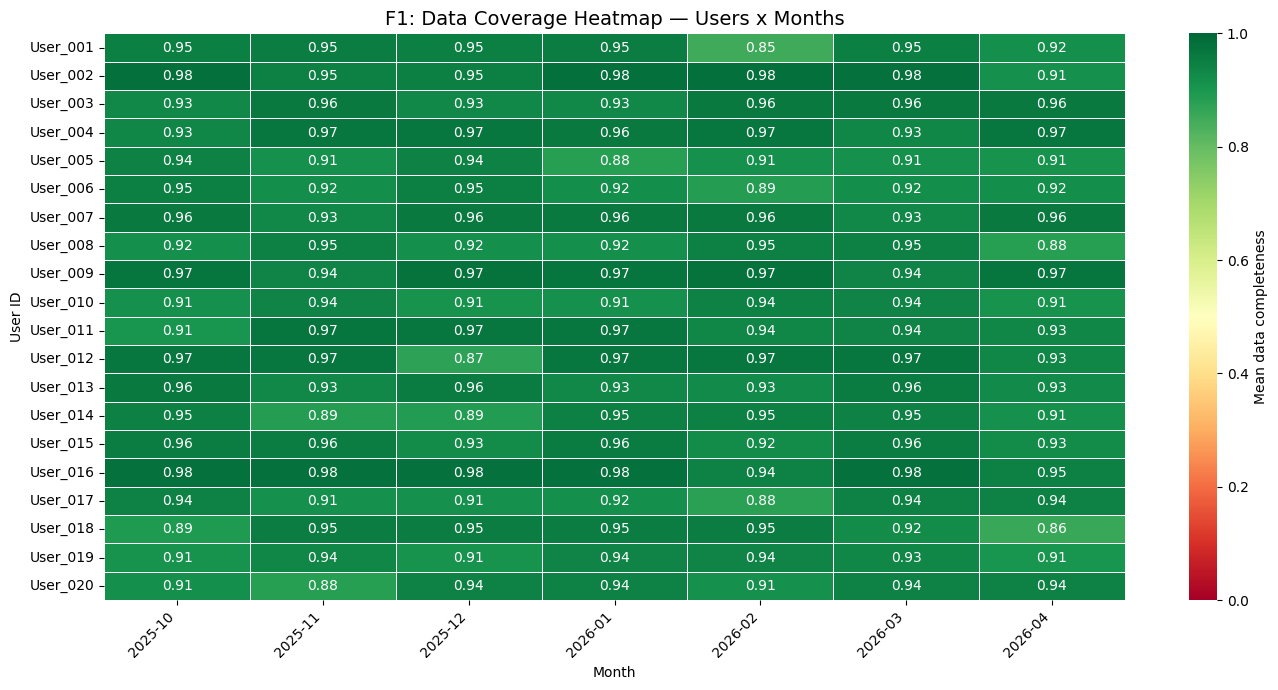

Saved: /kaggle/working/results/figures/F1_coverage_heatmap.png


In [11]:
# Cell 5 — Figure F1: Coverage heatmap (users x months, mean completeness)
import calendar

quality_df["date"] = pd.to_datetime(quality_df["date"])
quality_df["month"] = quality_df["date"].dt.to_period("M").astype(str)

pivot = (
    quality_df
    .groupby(["user_id", "month"])["data_completeness"]
    .mean()
    .unstack(level="month")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot,
    cmap="RdYlGn",
    vmin=0, vmax=1,
    annot=True, fmt=".2f",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Mean data completeness"}
)
ax.set_title("F1: Data Coverage Heatmap — Users x Months", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("User ID")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
f1_path = FIGURES_DIR / "F1_coverage_heatmap.png"
fig.savefig(f1_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {f1_path}")

In [12]:
# Cell 6 — Summary statistics
print("=== DATASET SUMMARY ===")
print(f"Users:          {activity_df['user_id'].nunique()}")
print(f"Date range:     {activity_df['date'].min()} to {activity_df['date'].max()}")
print(f"Total rows:     {len(activity_df):,}")
print()
comp_summary = quality_df['data_completeness'].describe()
print("Data completeness distribution:")
print(comp_summary)
print(f"\nDays >= 60% completeness: {(quality_df['data_completeness'] >= 0.60).mean()*100:.1f}%")

=== DATASET SUMMARY ===
Users:          20
Date range:     2025-10-01 to 2026-04-29
Total rows:     6,076,800

Data completeness distribution:
count    4220.000000
mean        0.939116
std         0.130063
min         0.000000
25%         0.945800
50%         0.956300
75%         0.967400
max         1.021500
Name: data_completeness, dtype: float64

Days >= 60% completeness: 98.1%


Alarm type distribution (after filtering):
alarm_type
automatic_inactivity    29
manual_alarm            19
wellbeing_change        11
Name: count, dtype: int64

Flag type distribution:
flag_type
red       10
yellow     5
Name: count, dtype: int64

Flagged users (5): ['User_003', 'User_011', 'User_012', 'User_014', 'User_020']


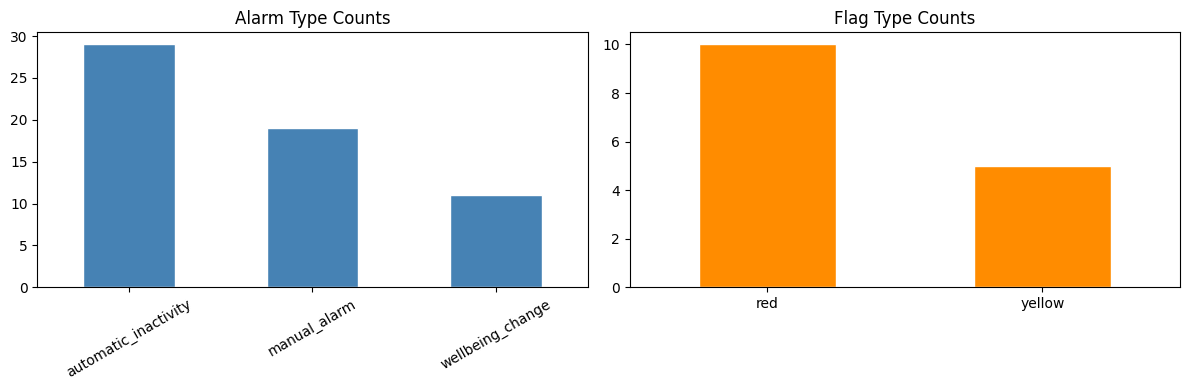

In [13]:
# Cell 7 — Alarm and flag counts, bar chart
print("Alarm type distribution (after filtering):")
print(alarms_df["alarm_type"].value_counts())
print()
print("Flag type distribution:")
print(flags_df["flag_type"].value_counts())
print()
flagged_users = flags_df["user_id"].unique()
print(f"Flagged users ({len(flagged_users)}): {sorted(flagged_users)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
alarms_df["alarm_type"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Alarm Type Counts")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

flags_df["flag_type"].value_counts().plot(
    kind="bar", ax=axes[1], color="darkorange", edgecolor="white"
)
axes[1].set_title("Flag Type Counts")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "alarm_flag_counts.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [14]:
# Cell 8 — Save outputs
quality_df.to_csv(TABLES_DIR / "quality_report.csv", index=False)
alarms_df.to_csv(TABLES_DIR / "alarms_clean.csv", index=False)
flags_df.to_csv(TABLES_DIR / "flags_clean.csv", index=False)
# Save small activity sample for downstream notebook loading checks
activity_df.head(50000).to_csv(TABLES_DIR / "activity_sample.csv", index=False)
print("Saved: quality_report.csv, alarms_clean.csv, flags_clean.csv, activity_sample.csv")

Saved: quality_report.csv, alarms_clean.csv, flags_clean.csv, activity_sample.csv
